# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
! pip install Pillow

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [3]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 11.22 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
!ls MNIST

processed  raw


In [5]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [6]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

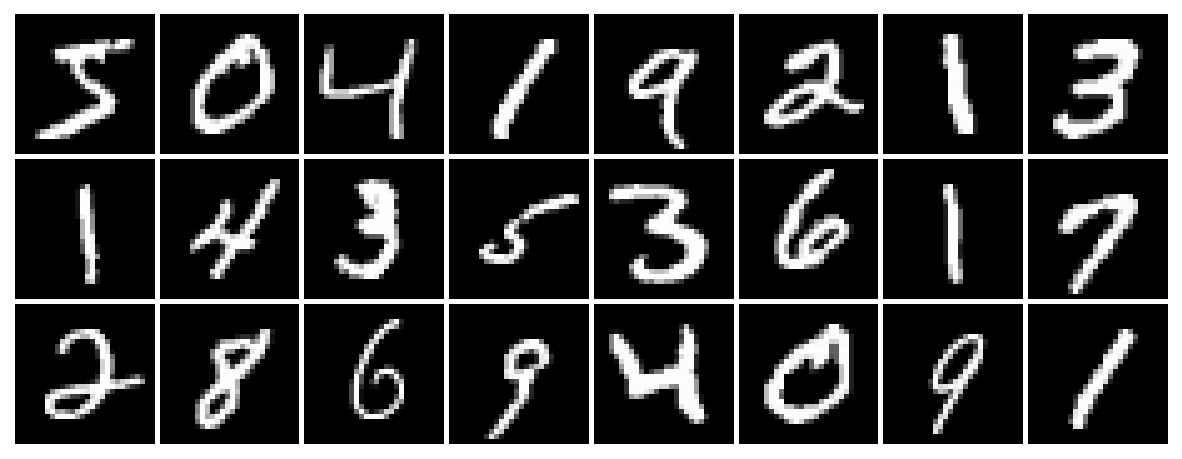

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


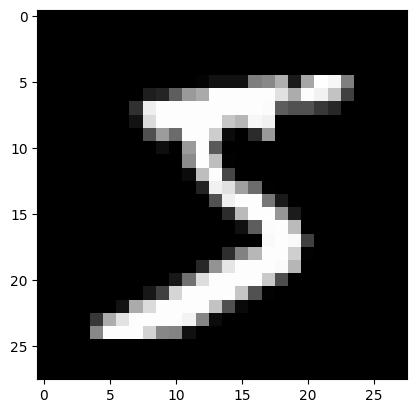

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.2602,  0.1633, -0.1779,  0.1815, -0.0836, -0.1653, -0.1708,  0.0415,
          0.0441, -0.1194],
        [ 0.1374, -0.0672, -0.0186,  0.5857,  0.0801, -0.0585, -0.0643,  0.3443,
          0.0173, -0.1708],
        [ 0.1156,  0.0634, -0.0998, -0.0518, -0.1222, -0.0999,  0.1456,  0.0798,
         -0.0800, -0.2527],
        [-0.1215, -0.1155, -0.0715,  0.0273,  0.0160,  0.2092, -0.1290,  0.0906,
          0.0167, -0.0187],
        [-0.1093,  0.0892,  0.1318, -0.0115,  0.3321,  0.2430, -0.0028,  0.1685,
         -0.1333,  0.1236]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Visualização do grafo computacional da perda (loss)

In [12]:
!pip install graphviz
!pip install git+https://github.com/szagoruyko/pytorchviz

  Cloning https://github.com/szagoruyko/pytorchviz to /tmp/pip-req-build-grdh11zs
  Running command git clone --filter=blob:none --quiet https://github.com/szagoruyko/pytorchviz /tmp/pip-req-build-grdh11zs
  Resolved https://github.com/szagoruyko/pytorchviz to commit 5cf04c13e601366f6b9cf5939b5af5144d55b887
  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4972 sha256=22b8cdd7ae692cbb43765f7fea2924b4817137db2701dcb4baa4dec519dc9aee
  Stored in directory: /tmp/pip-ephem-wheel-cache-7gph2jhn/wheels/8a/88/98/69bcb99aba99a6bba9b2b81439cbda0101df40c49e639c4216
Successfully built torchviz


In [13]:
from torchviz import make_dot, make_dot_from_trace
y_pred = model(Variable(x_train.view(-1,28*28)))
loss = criterion(y_pred, Variable(y_train))
loss


tensor(2.3645, grad_fn=<NllLossBackward0>)

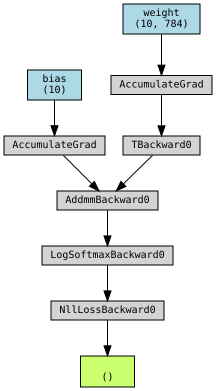

In [14]:
p = make_dot(loss, dict(model.named_parameters()))
p

### Laço de treinamento dos pesos

In [25]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print(f"Época {i+1}/{epochs}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Acurácia: {accuracy:.4f}")


Época 1/100
Loss: 0.2641
Acurácia: 0.9410
Época 2/100
Loss: 0.2628
Acurácia: 0.9410
Época 3/100
Loss: 0.2615
Acurácia: 0.9410
Época 4/100
Loss: 0.2602
Acurácia: 0.9410
Época 5/100
Loss: 0.2589
Acurácia: 0.9420
Época 6/100
Loss: 0.2576
Acurácia: 0.9430
Época 7/100
Loss: 0.2564
Acurácia: 0.9430
Época 8/100
Loss: 0.2552
Acurácia: 0.9430
Época 9/100
Loss: 0.2539
Acurácia: 0.9440
Época 10/100
Loss: 0.2527
Acurácia: 0.9440
Época 11/100
Loss: 0.2515
Acurácia: 0.9440
Época 12/100
Loss: 0.2504
Acurácia: 0.9440
Época 13/100
Loss: 0.2492
Acurácia: 0.9450
Época 14/100
Loss: 0.2480
Acurácia: 0.9450
Época 15/100
Loss: 0.2469
Acurácia: 0.9450
Época 16/100
Loss: 0.2458
Acurácia: 0.9460
Época 17/100
Loss: 0.2446
Acurácia: 0.9460
Época 18/100
Loss: 0.2435
Acurácia: 0.9460
Época 19/100
Loss: 0.2424
Acurácia: 0.9470
Época 20/100
Loss: 0.2414
Acurácia: 0.9470
Época 21/100
Loss: 0.2403
Acurácia: 0.9470
Época 22/100
Loss: 0.2392
Acurácia: 0.9480
Época 23/100
Loss: 0.2382
Acurácia: 0.9480
Época 24/100
Loss: 0

In [16]:
print('Final loss:', loss.item())

Final loss: 0.2654421031475067


### Visualizando gráfico de perda durante o treinamento

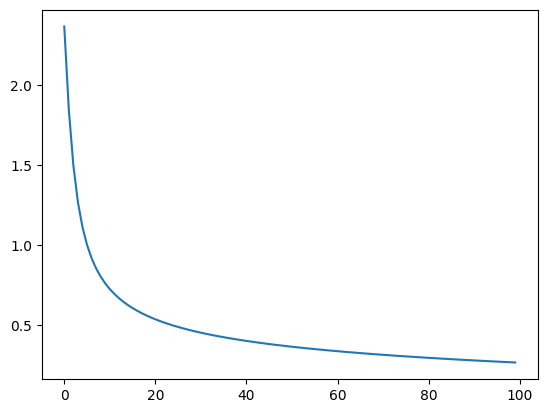

In [17]:
plt.plot(losses)

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [18]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.941


### Matriz de confusão com dados de treinamento e teste

In [19]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,96,0,1,0,0,0,1,0,0,2
1,0,110,1,0,0,0,2,2,1,0
2,0,1,91,1,0,1,0,1,2,1
3,0,0,0,88,0,2,0,0,0,0
4,0,0,1,0,102,2,1,2,0,3
5,0,2,0,1,0,81,0,0,2,1
6,1,0,1,1,2,2,90,0,0,0
7,0,1,1,1,0,0,0,111,0,3
8,0,2,2,0,0,2,0,0,82,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


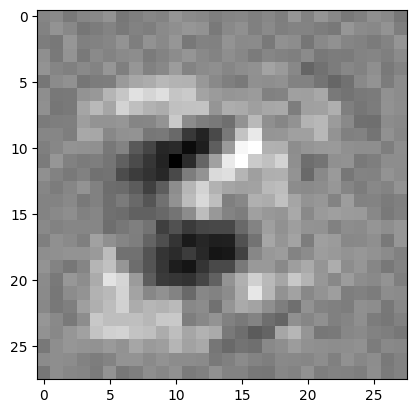

In [20]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

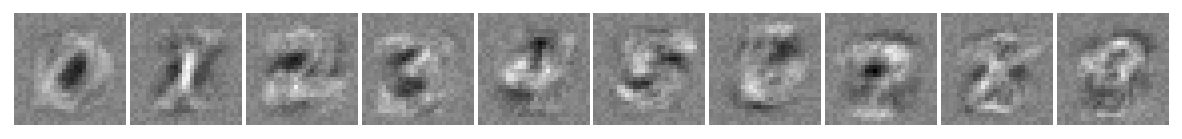

In [21]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [24]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print(f"Época {i+1}/{epochs}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Acurácia: {accuracy:.4f}")


Época 100/100
Loss: 0.2654
Acurácia: 0.9410


- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

In [26]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Flatten da entrada
    inputs = Variable(x_train.view(-1, 28 * 28))

    # Forward
    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    # Loss
    loss = criterion(outputs, Variable(y_train))

    # Backprop
    optimizer.zero_grad()
    loss.backward()

    # Visualizacao dos gradientes na classe 4
    print(f"\nÉpoca {i+1}/{epochs}")
    print("Gradientes dos pesos da classe 4:")
    print(model.weight.grad[4])

    print("Gradiente do bias da classe 4:")
    print(model.bias.grad[4])

    # Atualiza parâmetros
    optimizer.step()

    # Guarda o loss
    losses.append(loss.item())

    # Métrica de acurácia
    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print(f"Loss: {loss.item():.4f} | Acurácia: {accuracy:.4f}")

A saída de streaming foi truncada nas últimas 5000 linhas.
         9.3365e-06,  0.0000e+00,  0.0000e+00,  6.3455e-06,  3.5526e-05,
        -1.4174e-05, -1.1316e-04, -1.6275e-04, -1.5323e-04, -2.4854e-05,
         1.8317e-04,  4.4194e-05, -2.7118e-05,  2.5642e-04,  5.1634e-04,
         4.3538e-05,  7.6114e-04,  1.0087e-03, -3.7317e-04,  2.1034e-04,
         3.9122e-04,  2.6906e-04,  5.0178e-04,  4.4454e-04, -1.1753e-04,
         2.9233e-04,  4.9851e-04, -1.8460e-05,  4.4167e-06,  0.0000e+00,
         0.0000e+00,  7.3217e-07,  2.1464e-04,  1.7715e-04,  1.3354e-04,
        -1.7474e-04, -2.1419e-05,  1.1664e-04,  9.1139e-05, -2.8560e-04,
         2.0308e-04,  3.6526e-04, -1.3779e-04,  5.2715e-04,  8.4854e-04,
         8.3805e-04, -2.7517e-04,  1.7111e-04,  3.6016e-04,  2.2250e-04,
         1.6132e-04, -8.1938e-05, -4.6860e-04,  4.8601e-04,  3.7296e-04,
         1.7842e-05,  4.0364e-09,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         1.4682e-04,  1.9547e-04,  4.2356e-05, -3.5624e-04,  1.89

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?

**(1000, 768)**

2. Qual é o shape da saída da rede?

**(28*28, 10) ou  (768, 10)**

3. Qual é o número total de parâmetros da rede, incluindo o bias?

**A rede possui 7.850 parâmetros no total (7.840 pesos + 10 bias)**


# Aprendizados


Aprendemos como uma rede neural simples para MNIST é estruturada, incluindo o shape correto das entradas (784) e das saídas (10).

Também calculamos o número total de parâmetros (7.850) e entendemos como visualizar gradientes durante o treinamento.

Além disso, reforçamos como funções como torch.max ajudam a interpretar as previsões do modelo e como monitorar perda e acurácia a cada época.